# [LAB 10] 4-2. 분류 성능 평가지표
## 01. 준비작업
### 1. 라이브러리 참조

In [1]:
from hossam import load_data
from helpers import *
from pandas import DataFrame

import numpy as np

from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: develop


### 2. 데이터 가져오기
- 직전 단원과 동일한 데이터에 대해 전처리가 완료된 데이터를 준비한다.

In [2]:
origin = load_data('pima_indians_diabetes_preprocessed')
fit = my_logit.auto_logit(origin, 'Outcome', plot=False, report=False)

📚 피마 인디언 당뇨병 데이터셋에 대한 전처리 버전 - 결측치 처리, 이상치 처리, 라벨링 (출처: 자체 작업)



### 3. 혼동행렬 지표 얻기

In [3]:
y_true = np.asarray(fit.model.endog).astype(int)  # 실제 당뇨 여부(0/1)
proba = np.asarray(fit.predict())                 # 당뇨(1)일 예측확률
y_pred = (proba > 0.5).astype(int)                # 임계값 0.5로 이진화
cm = confusion_matrix(y_true, y_pred)             # 혼동행렬 배열

# 네 칸을 TN / FP / FN / TP로 분해(순서가 정해져 있다)
tn, fp, fn, tp = cm.ravel()

print(f"TN(정상인을 정상으로 맞힘) : {tn}")
print(f"FP(정상인을 당뇨로 헛짚음) : {fp}")
print(f"FN(당뇨 환자를 놓침) : {fn}")
print(f"TP(당뇨 환자를 맞힘) : {tp}")

TN(정상인을 정상으로 맞힘) : 420
FP(정상인을 당뇨로 헛짚음) : 55
FN(당뇨 환자를 놓침) : 107
TP(당뇨 환자를 맞힘) : 142


## #02. 정확도(Accuracy)
### 1. 직접 구하기
- 정확도는 전체 중에서 맞게 분류한 비율이다.
- 성적표로 치면 '100문제 중 몇 개 맞았나'에 해당한다. 가장 먼저 떠오르는 지표다
- 혼동행렬에서는 맞힌칸(TN, TP)을 전부 더해 전체로 나눈다.

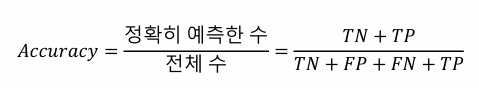

In [4]:
(tn+tp) / (tn+fp+fn+tp)

np.float64(0.7762430939226519)

### 2. 함수로 구하기
- sklearn의 함수로 사용하면 같은 값을 한 줄로 구할 수 있다.

In [6]:
acc = accuracy_score(y_true, y_pred)
acc

0.7762430939226519

### 3. 정확도의 함정(1) - 정답의 구성 비율 확인
- 우리 데이터에 당뇨(1)와 정상(0)이 각각 몇 명인지 센다

In [7]:
# 종속변수의 값별 개수
count =origin['Outcome'].value_counts()

# 종속변수의 값별 비율
ratio = origin['Outcome'].value_counts(normalize=True)

DataFrame({'인원수': count, '비율': ratio})

,인원수,비율
Outcome,,
0,475,0.656
1,249,0.344


### 4. 정확도의 함정(2) - 무조건 정상(0)이라고만 답하는 게으른 모형의 정확도

In [8]:
# 아무것도 계산하지 않고 무조건 '정상(0)'이라고만 답하는 모형
# --> 실제 정답의 길이만큼 0으로 채워진 배열을 만들어서 평가
y_lazy = np.zeros(len(y_true), dtype=int)

# 실제 정답과 모든 예측값이 0으로 채워진 배열에 대해 정확도 산출
lazy_acc = accuracy_score(y_true, y_lazy)
print(f"'무조건 정상' 모형의 정확도 : {lazy_acc:.1%}")

'무조건 정상' 모형의 정확도 : 65.6%


## #03. 정밀도(Precision)와 재현율(Recall)
### 1. 직접 구하기
- 정밀도 : 당뇨라고 예측한 사람 중 진짜 당뇨의 비율
    - 헛짚음(FP)이 적을수록 높아진다.
- 재현율 : 실제 당뇨 환자 중 모형이 찾아낸 비율
    - 놓침(FN)이 적을수록 높아진다.
    - 민감도(Sensitivity), TPR(True Positive Rate)이라고 부른다.

In [9]:
pre = tp / (tp + fp)
recall = tp / (tp + fn)
print(f'정밀도(Precision) = TP/(TP+FP) = {pre:.4f}')
print(f'재현율(Recall)    = TP/(TP+FN) = {recall:.4f}')

정밀도(Precision) = TP/(TP+FP) = 0.7208
재현율(Recall)    = TP/(TP+FN) = 0.5703


### 2. 함수로 구하기

In [11]:
# 직접 계산과 함수 계산이 같은지 확인
pre = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
print(f'정밀도(Precision) = {pre:.4f}')
print(f'재현율(Recall)    = {recall:.4f}')

정밀도(Precision) = 0.7208
재현율(Recall)    = 0.5703


## #04. 위양성률(Fallout, FPR)과 특이성(Specificity, TNR)
### 1. 직접 계산하기
- 앞의 두 지표가 양성(당뇨) 기준이었다면 이번 둘은 음성(정상) 기준이다.
    - 분모가 모두 실제 정상인 수(TN+FP)로 같다.
- 위양성율(FPR) -> 멀쩡한 사람 중 당뇨라고 잘못 부를 비율
- 특이성(TNR) -> 멀쩡한 사람 중 제대로 걸러낼 비율

In [12]:
fpr = fp / (fp + tn)  # 위양성률
tnr = 1 - fpr

print(f'위양성률(FPR) = FP/(FP+TN) = {fp}/{fp+tn} = {fpr:.4f}')
print(f'특이성(TNR)   = TN/(TN+FP) = {tn}/{tn+fp} = {tnr:.4f}')

위양성률(FPR) = FP/(FP+TN) = 55/475 = 0.1158
특이성(TNR)   = TN/(TN+FP) = 420/475 = 0.8842


## #05.F1 점수
### 1. 직접 계산
- 정밀도와 재현율은 한쪽을 올리면 다른 쪽이 내려가기 때문에 둘을 하나로 묶은 점수가 필요
- F1 점수는 정밀도와 재현율의 조화평균
    - 한쪽이 0에 가까우면 F1도 0에 가까워진다.
    - 즉, 한쪽만 잘해서는 점수를 딸 수 없다. 두 지표가 고르게 높아야한다.
- 식에 TN이 들어가지 않는다. 그래서 불균형 데이어테서 정확도보다 신뢰할만하다.

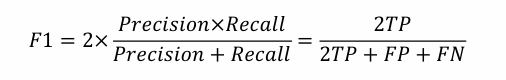

In [13]:
f1 = (2 * tp) / (2 * tp + fp + fn)
print(f'직접 계산 : {f1:.4f}')

직접 계산 : 0.6368


### 2. 함수계산

In [15]:
f1 = f1_score(y_true, y_pred)
print(f'함수계산 : {f1:.4f}')

함수계산 : 0.6368


## #06. ROC 곡선과 AUC
### 1. 임계값에 따른 지표 변화 실험

In [16]:
rows = []

for t in [0.3, 0.4, 0.5, 0.6, 0.7]: # 임계값을 0.3~0.7로 바꿔가며 관찰
    p = (proba > t).astype(int)     # 임계값 t로 이진화
    rows.append({
        "임계값" : t,
        "정확도" : accuracy_score(y_true, p),
        "정밀도" : precision_score(y_true, p),
        "재현율" : recall_score(y_true, p),
        "F1" : f1_score(y_true, p),
        "놓친 환자수(FN)" : confusion_matrix(y_true, p).ravel()[2]
    })

display(DataFrame(rows).round(3))

,임계값,정확도,정밀도,재현율,F1,놓친 환자수(FN)
0,0.300,0.749,0.604,0.783,0.682,54
1,0.400,0.769,0.665,0.663,0.664,84
2,0.500,0.776,0.721,0.570,0.637,107
3,0.600,0.782,0.783,0.506,0.615,123
4,0.700,0.754,0.803,0.378,0.514,155


### 2. 임계값에 따른 FPR, TPR 좌표 얻기
- roc_curve()는 임계값별 FPR, TPR 좌표를 한꺼번에 계산해 준다.
    - 첫 줄의 임계값 inf는 아무도 양성으로 판정하지 않는 상태(곡선의 시작점 0,0)를 뜻한다.

In [17]:
roc_fpr, roc_tpr, thresholds = roc_curve(y_true, proba)

print(f'계산된 임계값 개수 : {len(thresholds)}개')
df = DataFrame({'임계값' : thresholds, "FPR":roc_fpr, "TPR(재현율)":roc_tpr})
df.head()

계산된 임계값 개수 : 227개


,임계값,FPR,TPR(재현율)
0,inf,0.000,0.000
1,0.992,0.000,0.004
2,0.981,0.002,0.004
3,0.967,0.002,0.012
4,0.962,0.004,0.012


### 3. ROC 곡선 시각화

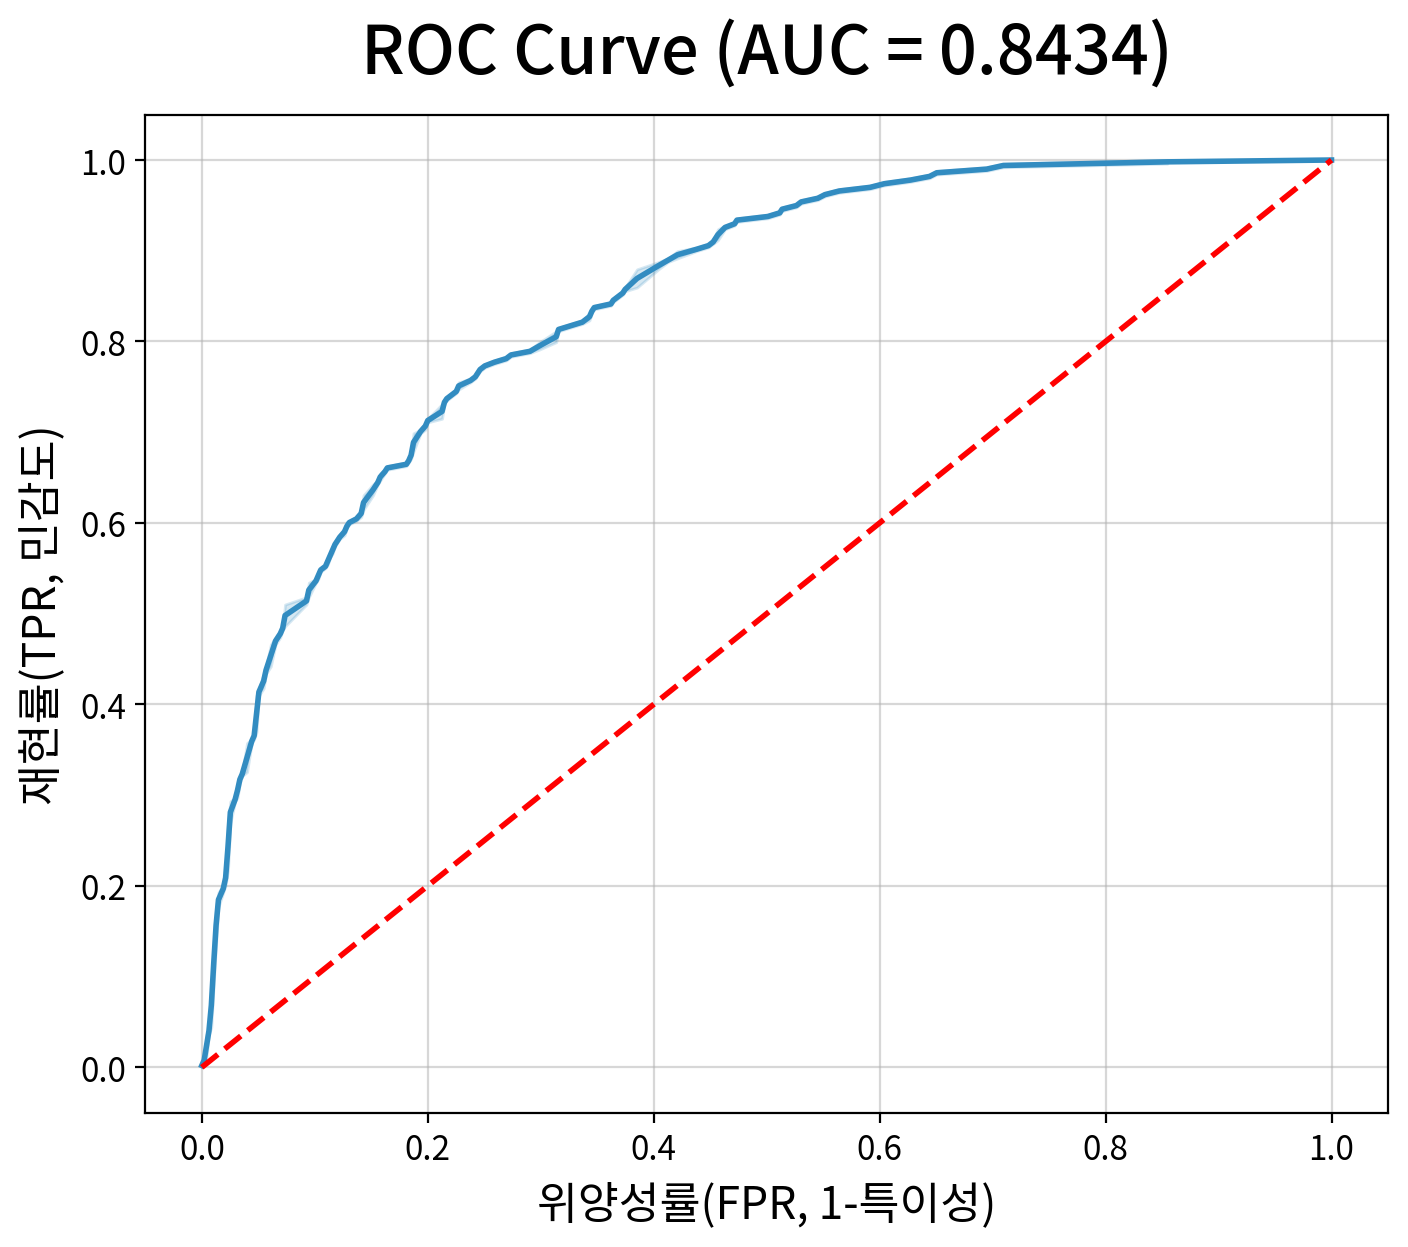

In [18]:
# ROC 곡선 아래 면적(AUC, Area Under Curve)계산
auc =roc_auc_score(y_true, proba)

# 그래프 초기화
fig, ax = my_plot.init(width=720, height=640, title=f'ROC Curve (AUC = {auc:.4f})',
                       xlabel='위양성률(FPR, 1-특이성)',
                       ylabel='재현률(TPR, 민감도)')

# ROC 곡선
my_plot.lineplot(x=roc_fpr, y=roc_tpr, color='#328cc1', ax=ax)

# 무작위로 찍었을 때의 기준선(대각선)
my_plot.lineplot(x=[0,1], y=[0,1], color='red', linestyle='--', ax=ax)

# 그래프 표시
my_plot.show()

## #06. 혼동행렬로 보는 오즈비
### 1. 진단 오즈비
- 혼동행렬을 통해 모형의 판정과 실제 상태가 얼마나 강하게 연결되는지가 계산할 수 있다.
- 이를 진단 오즈비라고 부른다.

In [19]:
odds_ratio = (tp * tn) / (fp * fn)

print(f'진단 오즈비 = (TP X TN)/(FP X FN)'
      f'=({tp} x {tn})/({fp} x {fn})'
      f'={odds_ratio:.4f}')

진단 오즈비 = (TP X TN)/(FP X FN)=(142 x 420)/(55 x 107)=10.1342
